###### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2025 sem 1

## Week 3 Tutorial



After working through this tutorial you should know
- how to define and compute joint, conditional, and marginal probabilities
- how to define a probability distribution for a discrete variable
- how to define a probability density function for a continuous variable
- how to compute entropy

## Probability practice

### Q1

Approximately 1% of women aged between 40 and 50 have breast cancer. 80% of mammogram screening tests detect breast cancer when it is there. 90% of mammograms DO NOT show breast cancer when it’s NOT there. Use this information to complete the following table with:

- the **joint probabilities** P(Cancer,Test) for each possible pair of cancer status and test result
- the **conditional probabilities** P(Test|Cancer) for each test result given cancer status

| Cancer | Test        | Joint prob. | Conditional prob. |
| ------ | ----------- | ----------- | ----------------- |
| Yes    | Positive    |             | 80%               |
| Yes    | Negative    |             |                   |
| No     | Positive    |             |                   |
| No     | Negative    |             | 90%               |

To complete the **conditional probabilities** column, note that the total probability of positive+negative tests for each condition (Cancer==Yes or Cancer==No) must sum to 100%

| Cancer | Test        | Joint prob. | Conditional prob. |
| ------ | ----------- | ----------- | ----------------- |
| Yes    | Positive    |             | 80%               |
| Yes    | Negative    |             | 20%               |
| No     | Positive    |             | 10%               |
| No     | Negative    |             | 90%               |

The **joint probability** can be computed as the conditional probability of test result given cancer state, times the probability of that state. In other words:

P(Cancer==x,Test==y) = P(Test==y|Cancer==x)P(Cancer==x)

The four values in the joint probability column should sum to 1.

| Cancer | Test        | Joint prob. | Conditional prob. |
| ------ | ----------- | ----------- | ----------------- |
| Yes    | Positive    | 0.8%        | 80%               |
| Yes    | Negative    | 0.2%        | 20%               |
| No     | Positive    | 9.9%        | 10%               |
| No     | Negative    | 89.1%       | 90%               |

### Q2
Given the table above, compute the **marginal probability** of a positive result in the mammogram screening test.

The **marginal probability** is the total probability of a positive result:

P(Test == Positive|Cancer == No)P(Cancer == No) + P(Test == Positive|Cancer == Yes)P(Cancer == Yes)

this is the sum of the two joint probabilities in the table above:

P(Test == Positive,Cancer == No) + P(Test == Positive,Cancer == Yes)

0.8 + 9.9 = 10.7%

### Q3
Suppose a woman in this age group receives a positive test result. What is the probability that she has cancer?

This is the conditional probability P(Cancer == Positive|Test == Yes). This is equivalent to the joint probability P(Test == Positive,Cancer == Yes) over the total probability of a positive result:

P(Test == Positive,Cancer == Yes) / P(Test == Yes)

0.8 / 10.7 = 7.5%

This result shows that even if a screening test returns a positive result, the actual chance of cancer is only 7.5%.

## Probability distribution

A probability distribution represents the probability of each possible event. For example, the probability distribution for a (fair) coin toss is:

- P(heads) = 0.5
- P(tails) = 0.5

Since the probability distribution represents all possible outcomes, the total probability should always sum to 1.

### Example 1. Empirical probability distribution

Estimate an empirical probability distribution for letters in English text by computing how often each letter (a,b,...z) appears in a sample text file.

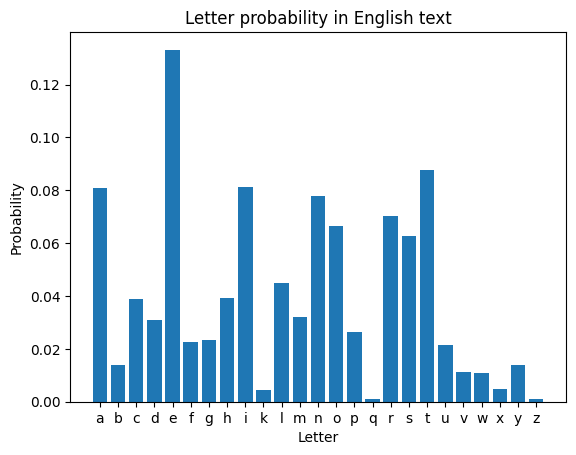

In [1]:
import matplotlib.pyplot as plt
from collections import Counter

# read a sample text (pre-processed to remove non-letters)
with open('mitchell1997.txt', 'r') as file:
    sample_text = file.read()

# count how often each letter occurs
letter_count = Counter(char for char in sample_text if char.isalpha())

# sort a-z
letters = sorted(letter_count.keys())
frequencies = [letter_count[letter] for letter in letters]

# empirical probability = proportion of time each letter appeared in sample
letter_probabilities = [freq / sum(frequencies) for freq in frequencies]

# plot the empirical pdf
plt.figure
plt.bar(letters, letter_probabilities)
plt.title('Letter probability in English text')
plt.xlabel('Letter')
plt.ylabel('Probability')
plt.show()

### Q4

Suppose you flip a fair coin 10 times. What are the odds that you will get exactly K heads, for each possible value of K (0,1,...10)? Write a function to simulate this experiment and empirically estimate the probability distribution.

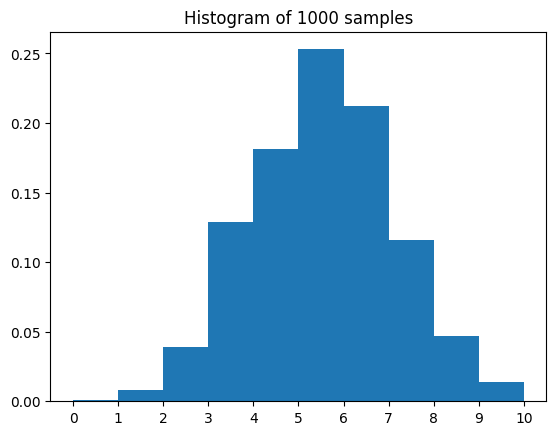

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 10 # simulate 10 coin tosses
P = 0.5 # P(heads)

# possible values for K
K = np.arange(0, N+1)

# simulate 10 coin flips, 1000 times (0=tails, 1=heads)
coin_flips = np.random.choice([0, 1], size=(N,1000), p=[1-P, P])

# compute the number of 1s (heads) in each attempt
count_heads = np.sum(coin_flips, axis=0)

# plot
plt.figure
plt.hist(count_heads, bins=K, density=True)
plt.title('Histogram of 1000 samples')
plt.xticks(K)
plt.show()

### Example 2. Binomial distribution

The theoretical probability distribution for the experiment described above is the **binomial distribution**. This distribution represents the probability of observing K "successes" after N trials, where each trial has a probability P of "success."

The SciPy library has functions for working with many common probability distributions. Let's compute the theoretical probability distribution for this task and see how closely the simulation matches.

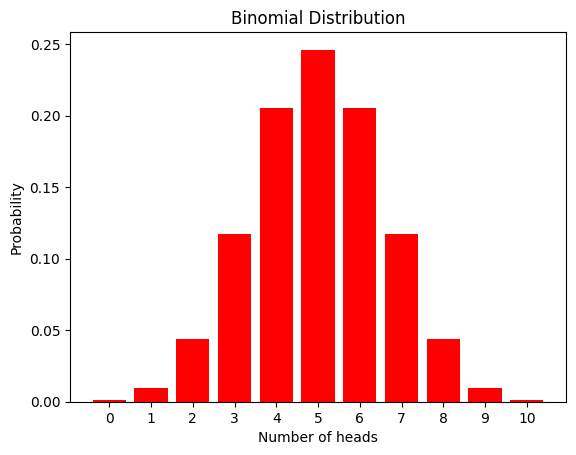

In [3]:
from scipy.stats import binom
import numpy as np

N = 10 # simulate 10 coin tosses
P = 0.5 # P(heads)

# possible values for K
K = np.arange(0, N+1)

# probability for each value of K
probability_density = binom.pmf(K, N, P)

# plot
plt.figure
plt.bar(K, probability_density, color='red')

plt.title('Binomial Distribution')
plt.xlabel('Number of heads')
plt.ylabel('Probability')
plt.xticks(K)
plt.show()

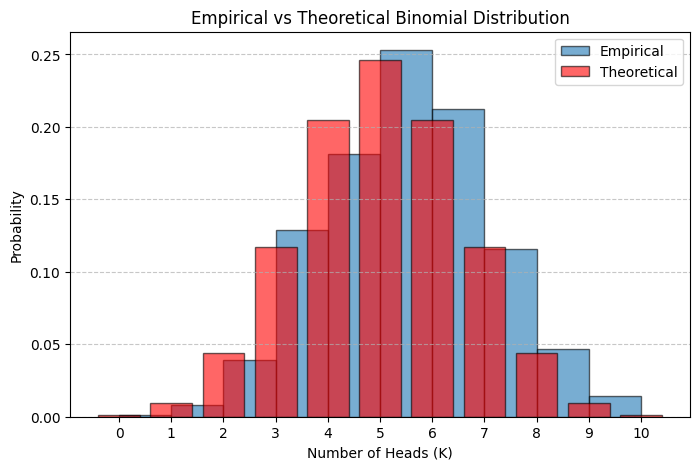

In [4]:
# Compare the Empirical vs Theoretical Binomial Distribution
plt.figure(figsize=(8, 5))
plt.hist(count_heads, bins=K, density=True, alpha=0.6, label="Empirical", edgecolor='black')
plt.bar(K, probability_density, alpha=0.6, label="Theoretical", color='red', edgecolor='black')

plt.title('Empirical vs Theoretical Binomial Distribution')
plt.xlabel('Number of Heads (K)')
plt.ylabel('Probability')
plt.xticks(K)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

### Probability density function

We can also compute probability distributions for continuous numeric variables. These are called probability density functions. For example, a normal (or Gaussian) distribution can be used to represent a continuous variable with a mean value of $\mu$ and a standard deviation of $\sigma$.

We can use numpy to sample a random variable with a normal distribution, and plot a histogram of the samples to get an empirical distribution.

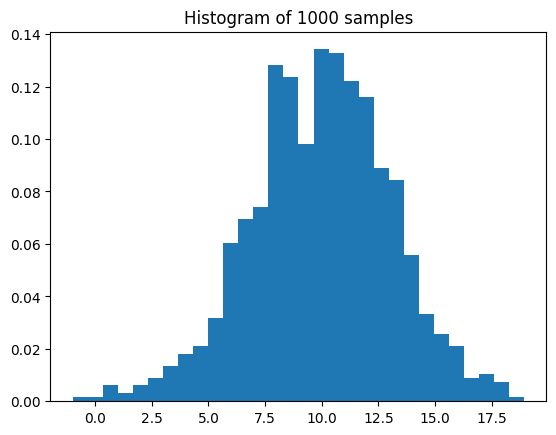

In [5]:
import numpy as np

# choose mu (mean) and sigma (standard deviation) of the normal distribution
mu = 10.0
sigma = 3.0

# empirically generate the probability density function by sampling 1000 times
samples = np.random.normal(loc=mu, scale=sigma, size=1000)

# plot the histogram of the samples
plt.hist(samples, bins=30, density=True)
plt.title('Histogram of 1000 samples')
plt.show()

Now let's plot the theoretical probability density function using SciPy.

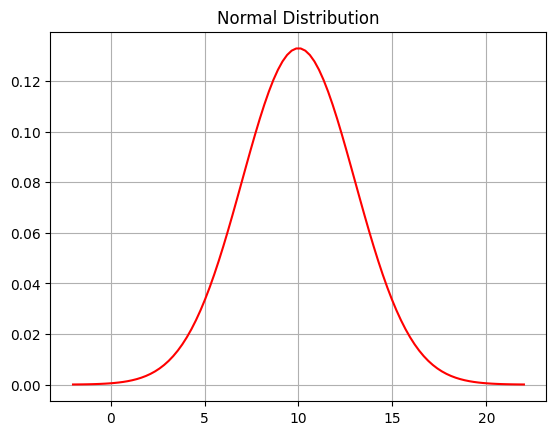

In [6]:
from scipy.stats import norm

# choose values for the x axis
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)

# compute probability density function at these x values
y = norm.pdf(x, mu, sigma)

# plot
plt.plot(x, y, color='red')
plt.title('Normal Distribution')
plt.grid(True)
plt.show()

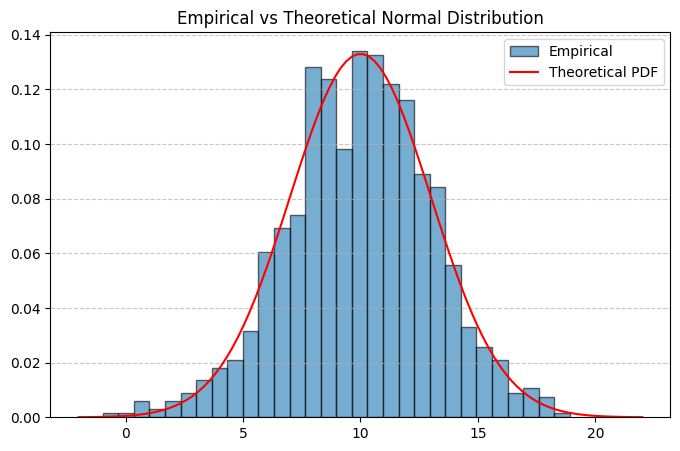

In [7]:
# Compare the Empirical vs Theoretical Normal Distribution
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=30, density=True, alpha=0.6, edgecolor='black', label="Empirical")
plt.plot(x, y, color='red', label="Theoretical PDF")

plt.title("Empirical vs Theoretical Normal Distribution")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Note that the area under this curve equals 1.

We can use the theoretical probability density function to calculate the probability of observing a given result, for example the probability of observing a result above or below a threshold. To do this we use the **cumululative probability** to calculate the area under the curve.

For example, we can compute the theoretical probability of observing a sample <= 2, and check how often this occured in our actual sample.

In [8]:
# pick a threshold value
value = 2

# compute the cumulative probability
prob = norm.cdf(value, mu, sigma)

print('The probability of observing a value <= '+str(value)+ ' is '+str(prob))

# check how many samples were <= threshold
count = np.count_nonzero(samples <= value)

print('The number of samples <= '+str(value)+ ' is '+str(count)+'/1000')

The probability of observing a value <= 2 is 0.0038303805675897365
The number of samples <= 2 is 8/1000


### Q5
Pick another threshold and compute the probability of observing samples **greater than** the threshold.

In [9]:
# pick a threshold value
value = 6

# recall that the probability density function must sum to 1
# so probability above the threshold is 1-(probability below)
prob = 1 - norm.cdf(value, mu, sigma)

print('The probability of observing a value > '+str(value)+ ' is '+str(prob))

# let's compare to the sample distribution
count = np.count_nonzero(samples > value)

print('The number of samples > '+str(value)+ ' is '+str(count)+'/1000')

The probability of observing a value > 6 is 0.9087887802741321
The number of samples > 6 is 909/1000


## Entropy

Entropy is a measure of the uncertainty or information in a variable. Entropy for a variable $X$ which can have states $x$, each with probability $p(x)$ is computed as:
$$ H(X) = -\sum_{x \in X} p(x) \log_2 p(x) $$

### Q6
Compute the entropy of a random letter generator which can generate any of the 26 English letters (a-z), each with equal probability.

In [10]:
# probability distribution for the random letter generator:
# 26 possible outcomes, each with P = 1/26
pk = (1.0/26)*np.ones((26,))

# compute entropy using the formula
h = - np.sum(np.multiply(pk,np.log2(pk)))

print('Entropy of a random letter generator = '+str(h))

# alternatively, we can use the entropy function from SciPy
from scipy.stats import entropy
h = entropy(pk, base=2)

print('Entropy of a random letter generator = '+str(h))

Entropy of a random letter generator = 4.700439718141092
Entropy of a random letter generator = 4.7004397181410935


### Q7
Compute the entropy of the actual probability distribution of letters in English text, using the empirical probability distribution computed earlier.

In [11]:
h = entropy(letter_probabilities, base=2)

print('Entropy of English text = '+str(h))

Entropy of English text = 4.1384378208546915


### Q8
You should get a lower value in Q7 than Q6. Why?

The distribution of letters in English text is not uniform random -- some letters are more common than others. For example, E occurs much more frequently than Q. A uniform random distribution has the highest possible entropy because it has the highest uncertainty. A distribution that is not uniform random is more predictable and therefore has lower entropy. The distribution of letters in English is not totally predictable (entropy == 0) but it predictable to some extent (for example, if you needed to guess the identity of a letter drawn randomly from an English text, you could guess "E" and you'd have a >10% of being correct!).

Does this result mean that English contains "less information" than a random sequence of letters? No, but it means that English contains less information than could, in theory, be conveyed by a 26-character sequence of the same length. Because of the statistical regularities in English letter sequences, some of the information is redundant. This means that the message conveyed by a letter sequence could be compressed into a shorter code without loss. (In fact, since there are many levels of redundancy in English text, e.g. in letter ordering as well as individual letters, text can be compressed quite a lot! This is the key idea behind many compression algorithms.)